# From an index to its result

Compare the original array with the values that indexing produces. Order and repeated picks are part of the result.

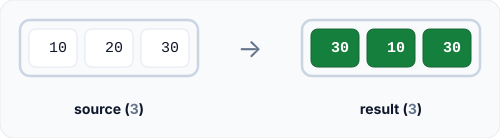

Original shape: (3,)
Index: [2, 0, 2]
Advanced indexing with integer arrays.
Axes 0 gather 3 positions in shape (3,).
Result shape: (3,)
The result preserves the index order, including repeated elements.


In [1]:
import numpy as np

import rainbow_tensor as rt

x = np.array([10, 20, 30])
rt.index(x, ([2, 0, 2],), show_result=True)

## Follow an output back to its source

The source highlights contain unique positions. The output still contains three elements, including two references to source position 2.

[(2,), (0,)]


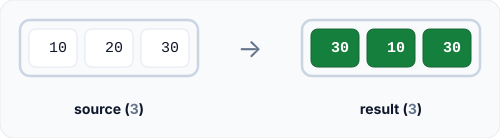

Original shape: (3,)
Index: [2, 0, 2]
Advanced indexing with integer arrays.
Axes 0 gather 3 positions in shape (3,).
Result shape: (3,)
The result preserves the index order, including repeated elements.


In [2]:
visual = rt.index(x, ([2, 0, 2],), show_result=True)
assert visual.index_mapping.result_count == 3
assert [visual.index_mapping.source_coord((i,)) for i in range(3)] == [(2,), (0,), (2,)]
print(list(visual.selected))
visual

## Reverse a slice

The result follows the slice order, even when it runs backwards.

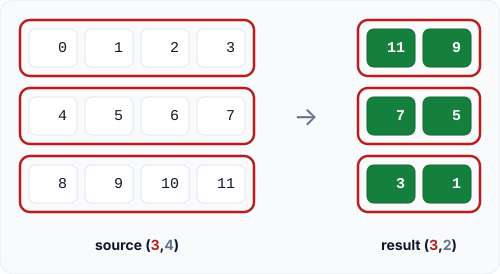

Original shape: (3, 4)
Index: ::-1, ::-2
Result shape: (3, 2)
Axis 0 is kept because slice ::-1 is used.
Axis 1 is kept because slice ::-2 is used.
The result preserves the index order, including repeated elements.


In [3]:
a = np.arange(12).reshape(3, 4)
rt.index(a, (slice(None, None, -1), slice(None, None, -2)), show_result=True)

## Keep trailing axes and insert a new one

Omitted trailing axes are full slices. Here the new axis has size one and the gathered rows stay in the requested order.

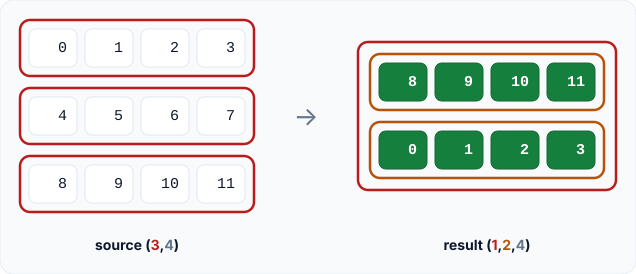

Original shape: (3, 4)
Index: None, [2, 0]
Advanced indexing with integer arrays.
Axes 0 gather 2 positions in shape (2,).
Result shape: (1, 2, 4)
The result preserves the index order, including repeated elements.


In [4]:
visual = rt.index(a, (None, [2, 0]), show_result=True)
assert visual.result_shape == a[None, [2, 0]].shape == (1, 2, 4)
visual

## A scalar result and an empty result

An integer on every axis selects one scalar. An empty slice selects no values.

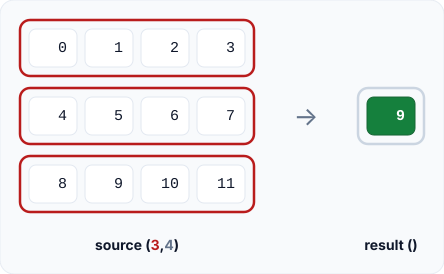

Original shape: (3, 4)
Index: 2, 1
Result shape: ()
Axis 0 is removed because integer index 2 is used.
Axis 1 is removed because integer index 1 is used.
The result preserves the index order, including repeated elements.


In [5]:
rt.index(a, (2, 1), show_result=True)

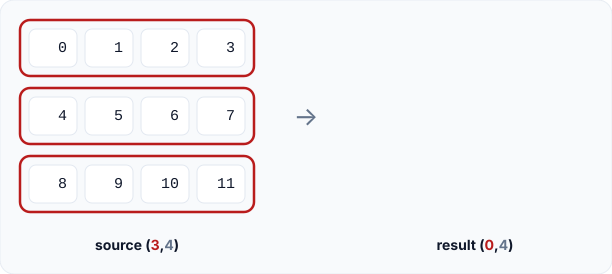

Original shape: (3, 4)
Index: 0:0
Result shape: (0, 4)
Axis 0 is kept because slice 0:0 is used.
Axis 1 is kept because slice : is used.
The result preserves the index order, including repeated elements.
The index selects no elements. The result is empty.


In [6]:
rt.index(a, (slice(0, 0),), show_result=True)

## Preview many outputs without expanding every coordinate

A shape tuple supplies generated values. The mapper keeps the long slice as a range and reads only displayed result positions.

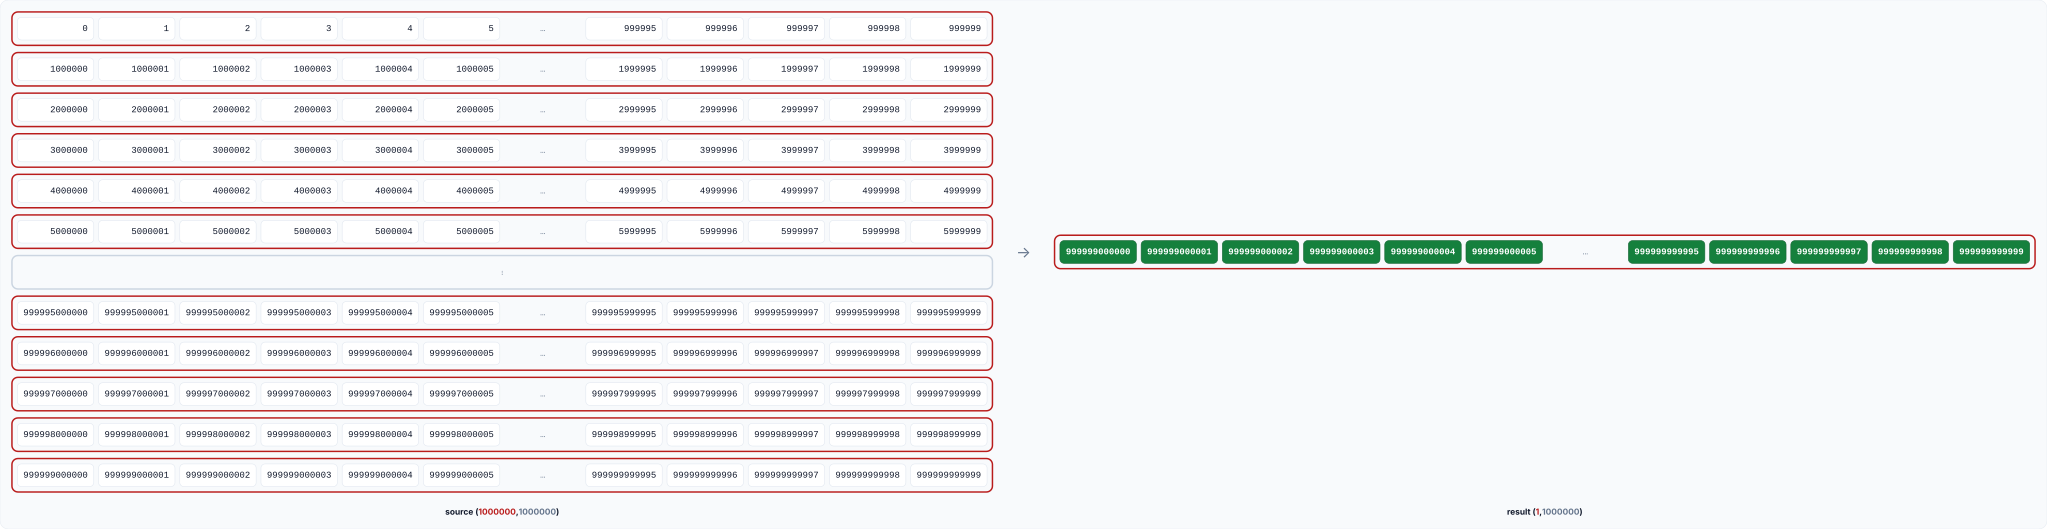

Original shape: (1000000, 1000000)
Index: [999999], :
Advanced indexing with integer arrays.
Axes 0 gather 1 position in shape (1,).
Result shape: (1, 1000000)
Large preview for tensor 0 (1000000, 1000000) draws at most 240 real cells from 1000000000000 total.
Hidden axes [0, 1] keep the head, selected positions, and tail.
Large preview for tensor 1 (1, 1000000) draws at most 240 real cells from 1000000 total.
Hidden axes [1] keep the head, selected positions, and tail.
The result preserves the index order, including repeated elements.


In [7]:
large = rt.index((1_000_000, 1_000_000), ([999_999], slice(None)), show_result=True)
assert large.index_mapping.result_count == 1_000_000
assert large.index_mapping.source_coord((0, 999_999)) == (999_999, 999_999)
large